In [34]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
from flextrees.datasets.tabular_datasets import ildp,magic,credit2,car
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os
import matplotlib.pyplot as plt

In [35]:
datasets = ['bank',
            'adult','nursery','bcancer',
            'ildp','credit','car',
            'covertype','magic','pendig']

In [36]:
datasets2 = ['nursery','car',
            'covertype','pendig']

In [37]:
Nclients = 10

In [38]:
path = os.path.abspath('')

In [39]:
def processDataFrame(dataframe,dataframe1,datasets):
    global_dataframeFed = dataframe[[x for x in dataframe.columns if 'global' in x]]
    global_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'global' in x]]
    local_dataframeFed = dataframe[[x for x in dataframe.columns if 'local' in x]]
    local_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'local' in x]]
    stats_dataframe = pd.concat([dataframe.iloc[:,0],global_dataframeFed,global_dataframeNFed],axis=1)
    auxglobaldataframe = pd.concat([global_dataframeFed,global_dataframeNFed],axis=1)
    auxlocaldataframe = pd.concat([local_dataframeFed,local_dataframeNFed],axis=1)
    filter = np.array(range(auxglobaldataframe.shape[0])).reshape(-1,6)
    num_datasets = filter.shape[0]
    global_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxglobaldataframe.columns)
    local_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxlocaldataframe.columns)
    for i in range(num_datasets):
        global_mean.iloc[i] = auxglobaldataframe.iloc[filter[i]].mean(axis=0)
        local_mean.iloc[i] = auxlocaldataframe.iloc[filter[i]].mean(axis=0)
    return stats_dataframe,global_mean,local_mean

In [40]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_acc_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    local_mean = local_mean.round(decimals=3)
    global_mean = global_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe



In [41]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_acc_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
local_mean = local_mean.round(decimals=3)
global_mean = global_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# Accuracy IID

In [42]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 40.399999999999864, p-value 3.8011149339212125e-07
{'o_s_Wmv_cw_global': 4.108333333333333, 'o_s_Wmv_aw_global': 3.9583333333333335, 's_c_b_nb_Wmv_aw_global': 3.925, 'FRF_global': 3.7333333333333334, 'DistBoost_global': 2.691666666666667, 'PreWeak_global': 4.583333333333333, 'AdaBoost_global': 5.0}


[4.108333333333333, 3.9583333333333335, 3.925, 3.7333333333333334, 2.691666666666667, 4.583333333333333, 5.0]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


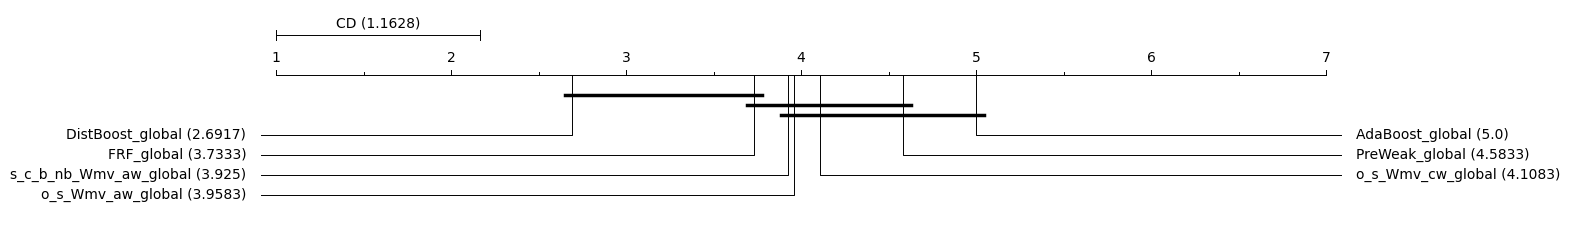

In [43]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy NIID-QS

In [44]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 10.610714285714266, p-value 0.10117903099138026
{'o_s_Wmv_cw_global': 3.925, 'o_s_Wmv_aw_global': 4.391666666666667, 's_c_b_nb_Wmv_aw_global': 3.675, 'FRF_global': 4.6, 'DistBoost_global': 3.6416666666666666, 'PreWeak_global': 3.7333333333333334, 'AdaBoost_global': 4.033333333333333}


[3.925, 4.391666666666667, 3.675, 4.6, 3.6416666666666666, 3.7333333333333334, 4.033333333333333]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


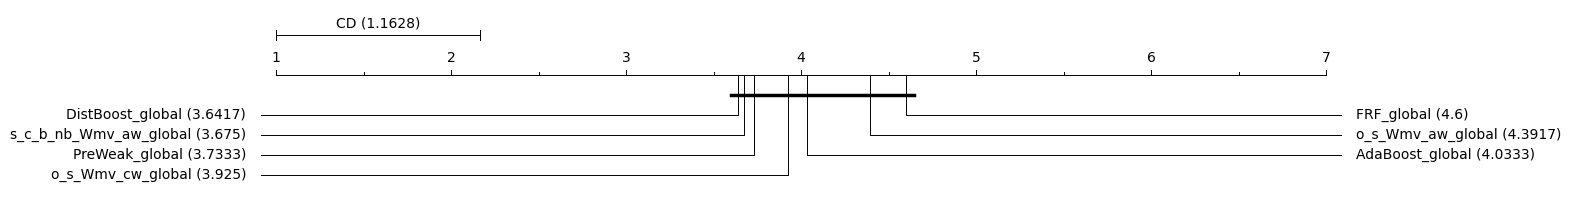

In [45]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy noIID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 51.39642857142849, p-value 2.5258047875453826e-09
{'o_s_Wmv_cw_global': 4.216666666666667, 'o_s_Wmv_aw_global': 4.941666666666666, 's_c_b_nb_Wmv_aw_global': 5.15, 'FRF_global': 3.566666666666667, 'DistBoost_global': 2.8916666666666666, 'PreWeak_global': 3.4916666666666667, 'AdaBoost_global': 3.7416666666666667}
[4.216666666666667, 4.941666666666666, 5.15, 3.566666666666667, 2.8916666666666666, 3.4916666666666667, 3.7416666666666667]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\3109710221.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


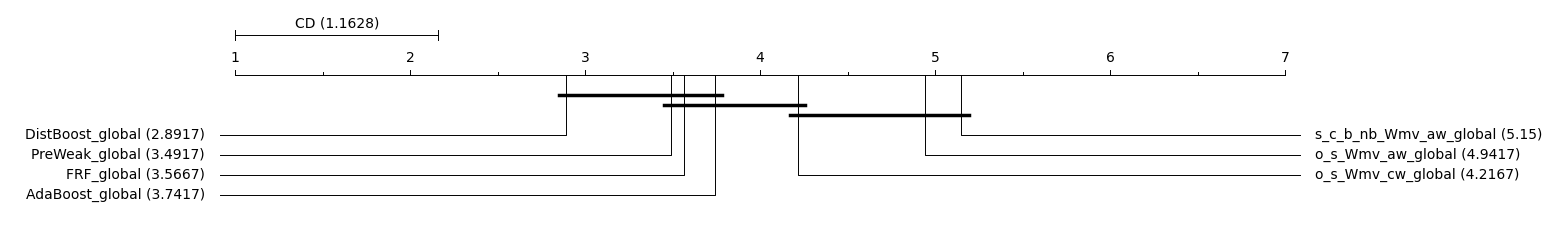

In [46]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy noIID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 22.616071428571445, p-value 0.000935809484289396
{'o_s_Wmv_cw_global': 4.520833333333333, 'o_s_Wmv_aw_global': 4.458333333333333, 's_c_b_nb_Wmv_aw_global': 4.833333333333333, 'FRF_global': 3.7083333333333335, 'DistBoost_global': 2.3541666666666665, 'PreWeak_global': 3.6041666666666665, 'AdaBoost_global': 4.520833333333333}


[4.520833333333333, 4.458333333333333, 4.833333333333333, 3.7083333333333335, 2.3541666666666665, 3.6041666666666665, 4.520833333333333]
1.838600493723478


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\1176126289.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


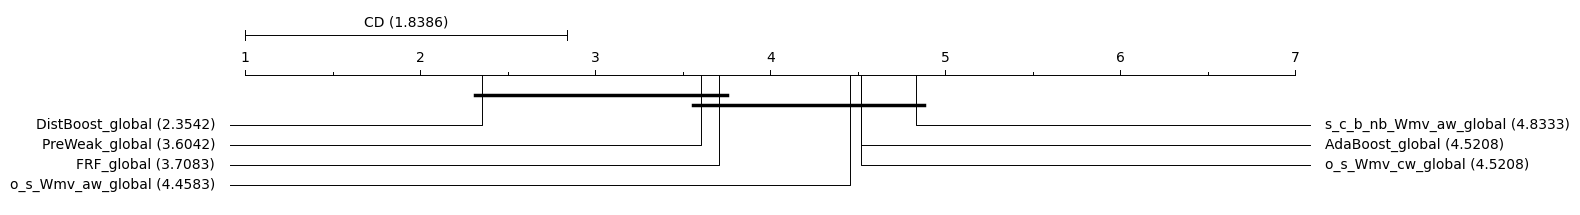

In [47]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1 Results

In [48]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_f1_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    local_mean = local_mean.round(decimals=3)
    global_mean = global_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe

In [49]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_f1_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
local_mean = local_mean.round(decimals=3)
global_mean = global_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# F1-score IID

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 37.36428571428564, p-value 1.495166246590074e-06
{'o_s_Wmv_cw_global': 3.575, 'o_s_Wmv_aw_global': 3.408333333333333, 's_c_b_nb_Wmv_aw_global': 3.4166666666666665, 'FRF_global': 4.925, 'DistBoost_global': 3.408333333333333, 'PreWeak_global': 4.516666666666667, 'AdaBoost_global': 4.75}
[3.575, 3.408333333333333, 3.4166666666666665, 4.925, 3.408333333333333, 4.516666666666667, 4.75]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\1993031218.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


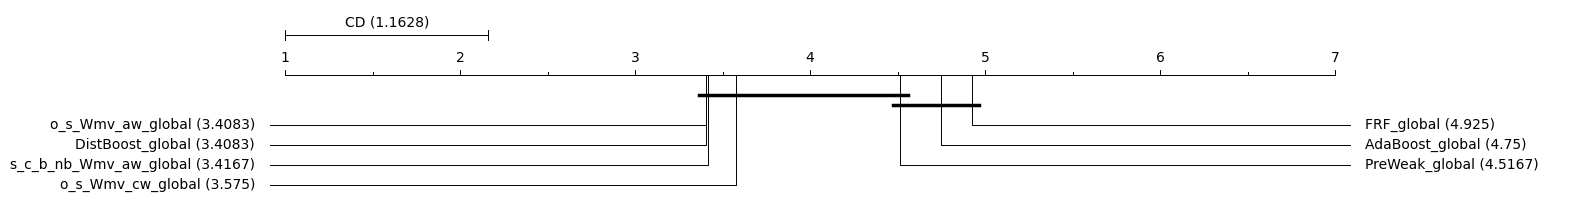

In [50]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID QS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 60.91964285714289, p-value 7.507039434528906e-11
{'o_s_Wmv_cw_global': 3.475, 'o_s_Wmv_aw_global': 3.6166666666666667, 's_c_b_nb_Wmv_aw_global': 3.0083333333333333, 'FRF_global': 5.783333333333333, 'DistBoost_global': 4.35, 'PreWeak_global': 3.85, 'AdaBoost_global': 3.9166666666666665}
[3.475, 3.6166666666666667, 3.0083333333333333, 5.783333333333333, 4.35, 3.85, 3.9166666666666665]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\21045223.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


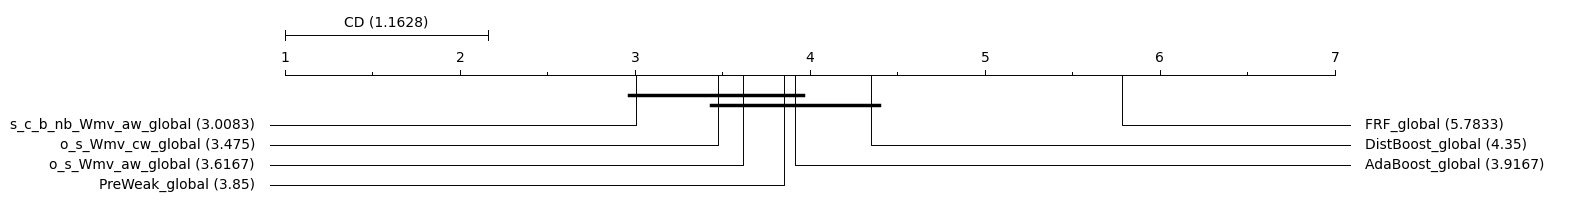

In [51]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 36.07142857142844, p-value 2.669913440001004e-06
{'o_s_Wmv_cw_global': 3.091666666666667, 'o_s_Wmv_aw_global': 3.658333333333333, 's_c_b_nb_Wmv_aw_global': 3.933333333333333, 'FRF_global': 5.308333333333334, 'DistBoost_global': 4.083333333333333, 'PreWeak_global': 3.7, 'AdaBoost_global': 4.225}
[3.091666666666667, 3.658333333333333, 3.933333333333333, 5.308333333333334, 4.083333333333333, 3.7, 4.225]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\3559529400.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


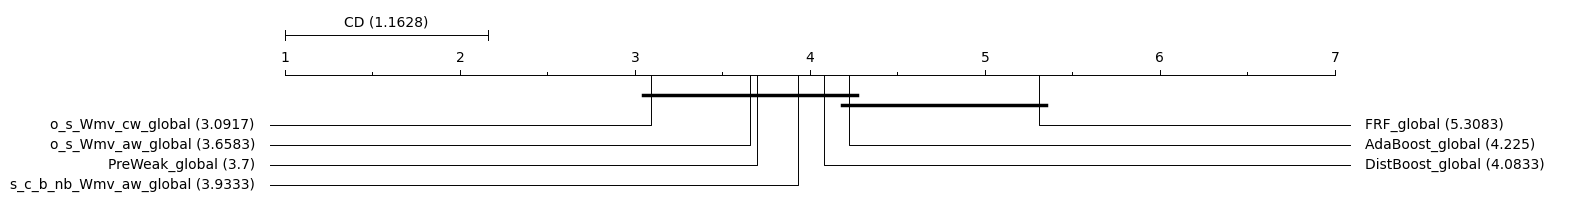

In [52]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 19.59375, p-value 0.003269994666388776
{'o_s_Wmv_cw_global': 3.5208333333333335, 'o_s_Wmv_aw_global': 3.4583333333333335, 's_c_b_nb_Wmv_aw_global': 3.8958333333333335, 'FRF_global': 4.583333333333333, 'DistBoost_global': 2.875, 'PreWeak_global': 4.458333333333333, 'AdaBoost_global': 5.208333333333333}
[3.5208333333333335, 3.4583333333333335, 3.8958333333333335, 4.583333333333333, 2.875, 4.458333333333333, 5.208333333333333]
1.838600493723478


C:\Users\mario\AppData\Local\Temp\ipykernel_26200\802260200.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


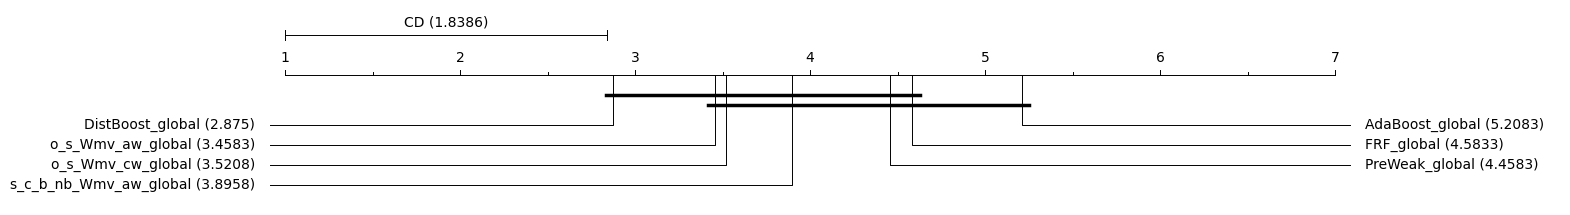

In [53]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()
